#imports

In [954]:
from sklearn.datasets import make_regression
import numpy as np

#creating dataset and output column

 4 rows<br>
 1 column in X<br>
 1 output column<br>
noise = 80<br>


In [955]:
X,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1,noise=80,random_state=13)

In [956]:
X,y

(array([[-0.71239066],
        [ 0.45181234],
        [-0.04450308],
        [ 0.75376638]]),
 array([  7.21786552,  16.04609925, -27.83756166, 144.36688189]))

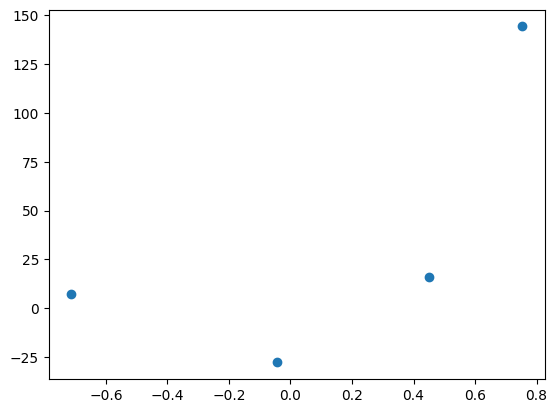

In [957]:
import matplotlib.pyplot as plt
plt.scatter(X,y) # plot X and y

# Lets apply OLS (sklearn)

In [958]:
from sklearn.linear_model import LinearRegression

In [959]:
reg = LinearRegression()
reg.fit(X,y)

LinearRegression()

In [960]:
y_pred = reg.predict(X)
y_pred

array([-29.65662909,  61.55941724,  22.67278832,  85.21770852])

In [961]:
reg.coef_

array([78.35063668])

In [962]:
reg.intercept_

np.float64(26.15963284313262)

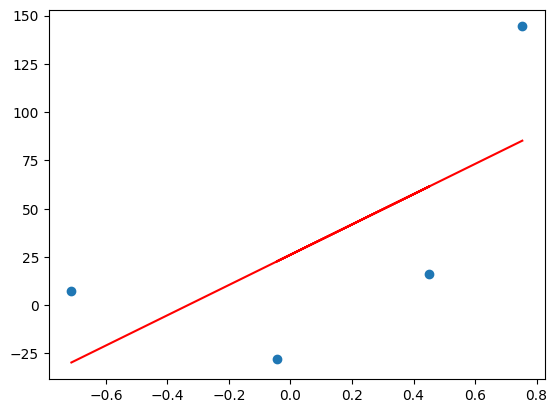

In [963]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')

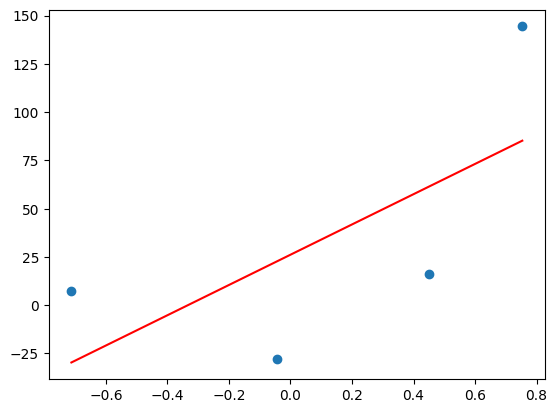

In [964]:
plt.scatter(X,y)
plt.plot([X[0],X[-1]],[y_pred[0],y_pred[-1]],color='red')
#plt.plot([1,2,3],[2,4,55],color='red') # this line is garbage -> only for intuition how plot actually works

---
# Lets apply Gradient Descent assuming slope is constant m = 78.35

# and let's assume the starting value for intercept b = 0
---

# m is constant  = 78.35

#b = 100 initially


In [965]:
y_pred = ((78.35 * X) + 100)
y_pred

array([[ 44.18419163],
       [135.39949674],
       [ 96.51318381],
       [159.05759577]])

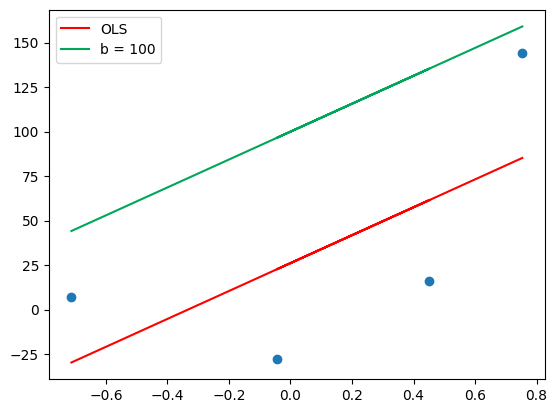

In [966]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS') # original
plt.plot(X,y_pred,color='#00a65a',label='b = 100') # when b = 100 ->before iteration 1
plt.legend()
plt.show()

# Iteration 1

In [982]:
# Iteration 1
m = 78.35
b = 100

loss_slope = -2 * np.sum(y - m*X.ravel() - b) # ravel() converts a tensor into an 1D array
loss_slope

np.float64(590.7223659179078)

In [968]:
# Lets take learning rate = 0.1
lr = 0.1

step_size = loss_slope*lr
step_size

np.float64(59.072236591790784)

In [969]:
# Calculating the new intercept
b = b - step_size
b # new b

np.float64(40.927763408209216)

# new b  =  40.92

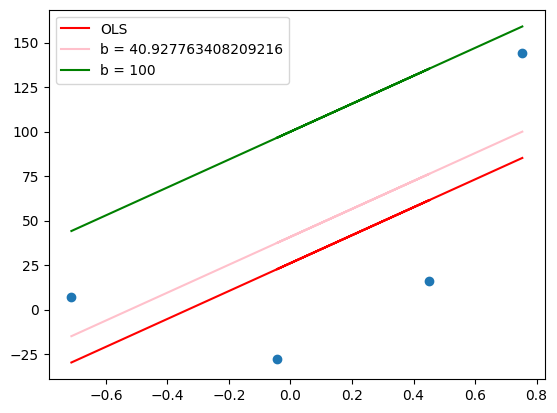

In [970]:
y_pred1 = ((m * X) + b)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS') # actual
plt.plot(X,y_pred1,color='pink',label='b = {}'.format(b))  # when b is 40.something
plt.plot(X,y_pred,color='green',label='b = 100') # when b was 100
plt.legend()
plt.show()

# Iteration 2

In [971]:
# Iteration 2
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(118.14447318358157)

In [972]:
step_size = loss_slope*lr
step_size

np.float64(11.814447318358157)

In [973]:
b = b - step_size
b

np.float64(29.11331608985106)

# the yellow line getting close to the red line

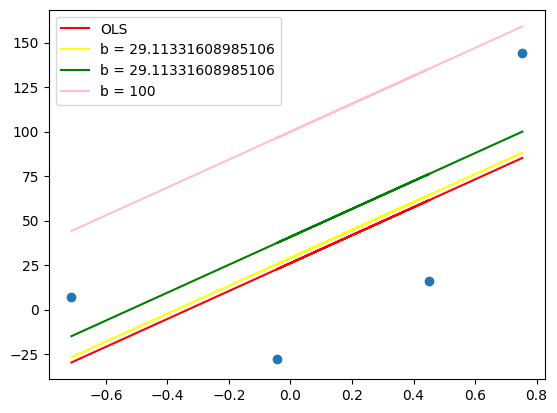

In [974]:
y_pred2 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS') # original
plt.plot(X,y_pred2,color='yellow',label='b = {}'.format(b)) # when b = 29.11
plt.plot(X,y_pred1,color='green',label='b = {}'.format(b)) # when b = 40.something
plt.plot(X,y_pred,color='pink',label='b = 100') # when b = 100
plt.legend()
plt.show()

# Iteration 3

In [975]:
# Iteration 3
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(23.62889463671634)

In [976]:
step_size = loss_slope*lr
step_size

np.float64(2.362889463671634)

In [977]:
b = b - step_size
b

np.float64(26.750426626179426)

# the black line almost overlaped the red one


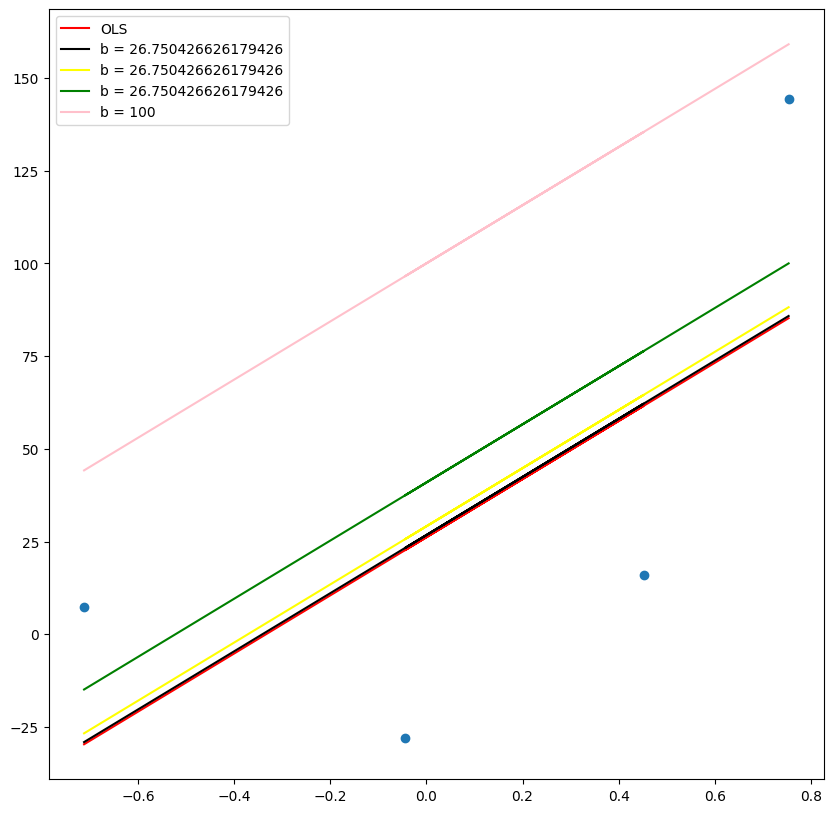

In [978]:
y_pred3 = ((78.35 * X) + b).reshape(4)

plt.figure(figsize=(10,10))
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS') # original
plt.plot(X,y_pred3,color='black',label='b = {}'.format(b)) # when b = 26.75
plt.plot(X,y_pred2,color='yellow',label='b = {}'.format(b)) # when b = 29.something
plt.plot(X,y_pred1,color='green',label='b = {}'.format(b)) # when b = 40.something
plt.plot(X,y_pred,color='pink',label='b = 100') # when b = 100
plt.legend()
plt.show()

# using for loop

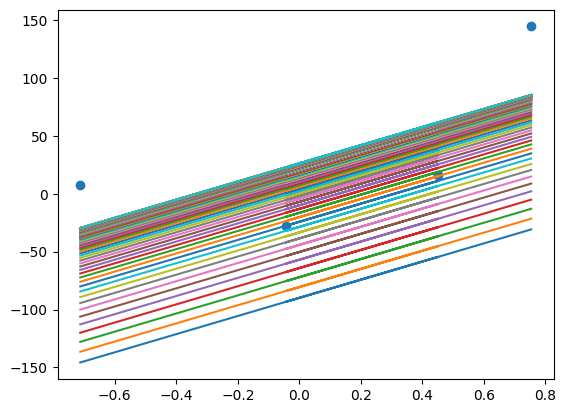

In [979]:
b = -100
m = 78.35
lr = 0.01

epochs = 100

for i in range(epochs):
  loss_slope = -2 * np.sum(y - m*X.ravel() - b)
  b = b - (lr * loss_slope)

  y_pred = m * X + b

  plt.plot(X,y_pred)

plt.scatter(X,y)

at this point the diff is not that significant: 77


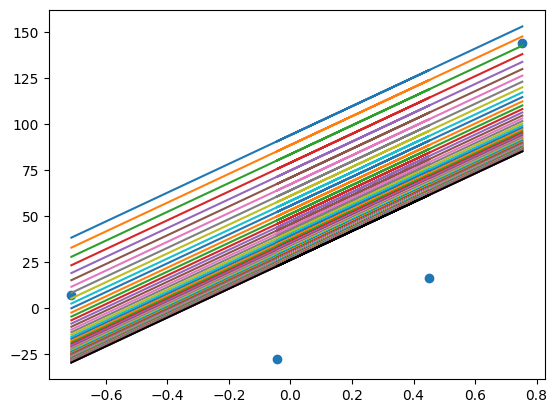

In [980]:
b = 100
m = 78.35
lr = 0.01

epochs = 100

for i in range(epochs):
  loss_slope = -2 * np.sum(y - m*X.ravel() - b)
  sub = (lr * loss_slope)
  if abs(sub) < 0.01:
    print("at this point the diff is not that significant:",i)
    break
  b = b - sub
  y_pred = m * X + b
  plt.plot(X,y_pred)


plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='black')

at this point the diff is not that significant: 83


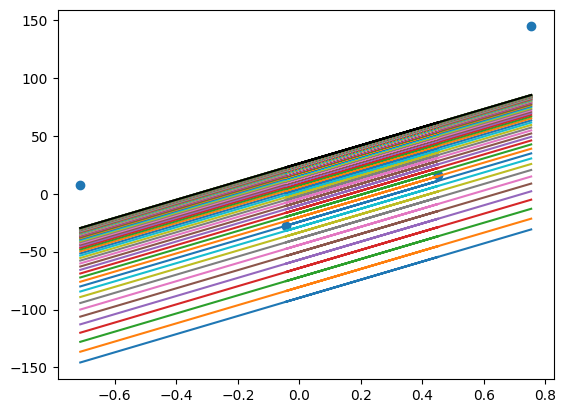

In [981]:
b = -100
m = 78.35
lr = 0.01
epochs = 100

for i in range(epochs):
  loss_slope = -2 * np.sum(y - m*X.ravel() - b)
  sub = (lr * loss_slope)
  if abs(sub) < 0.01:
    print("at this point the diff is not that significant:",i)
    break
  b = b - sub
  y_pred = m * X + b
  plt.plot(X,y_pred)


plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='black')